# Ornstein–Uhlenbeck Process: mean reversion and temporal dependence

This experiment studies the stochastic differential equation

$$dX_t=\theta(\mu-X_t)\,dt+\sigma\,dW_t$$

through exact moment formulas and Euler–Maruyama simulation. The focus is on what each parameter controls, how the process approaches stationarity, and why mean reversion does not eliminate randomness.

## 1. Problem

For $\theta>0$, the drift points toward the level $\mu$, while Brownian noise continually perturbs the process. We ask:

1. How do $E[X_t]$ and $\operatorname{Var}(X_t)$ evolve from a fixed initial value $X_0=x_0$?
2. What stationary distribution is reached in the long run?
3. How quickly does the process forget a displacement from its mean?
4. What do $\theta$, $\mu$, and $\sigma$ change separately?
5. Does Euler–Maruyama reproduce the theoretical mean, variance, and autocorrelation when the time step is small?

## 2. Mathematical Background

Set $Y_t=e^{\theta t}(X_t-\mu)$. Itô's product rule gives

$$dY_t=\sigma e^{\theta t}\,dW_t.$$

Integrating and multiplying by $e^{-\theta t}$ yields the exact representation

$$X_t=\mu+(x_0-\mu)e^{-\theta t}
      +\sigma\int_0^t e^{-\theta(t-s)}\,dW_s.$$

The stochastic integral has mean zero. By Itô isometry, its variance is

$$\sigma^2\int_0^t e^{-2\theta(t-s)}\,ds
=\frac{\sigma^2}{2\theta}\left(1-e^{-2\theta t}\right).$$

Euler–Maruyama replaces a small interval of Brownian motion with $\sqrt{\Delta t}Z_k$, where $Z_k\sim N(0,1)$:

$$X_{k+1}=X_k+\theta(\mu-X_k)\Delta t+\sigma\sqrt{\Delta t}\,Z_k.$$

## 3. Theoretical Result

For deterministic $X_0=x_0$,

$$E[X_t]=\mu+(x_0-\mu)e^{-\theta t},$$

$$\operatorname{Var}(X_t)=\frac{\sigma^2}{2\theta}\left(1-e^{-2\theta t}\right).$$

As $t\to\infty$,

$$X_t\ \xrightarrow{d}\ N\!\left(\mu,\frac{\sigma^2}{2\theta}\right).$$

In stationarity, observations separated by lag $\tau$ have autocorrelation

$$\rho(\tau)=e^{-\theta\tau}.$$

The mean displacement is multiplied by $e^{-\theta t}$, so its half-life is

$$t_{1/2}=\frac{\log 2}{\theta}.$$

Thus $\mu$ sets the long-run level, $\sigma$ controls the strength of random shocks, and $\theta$ controls both the speed of mean reversion and, together with $\sigma$, the stationary variance.

## 4. Numerical Experiment

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from scipy.stats import norm

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "src" / "ou_process.py").exists(), "Run from the repository root or notebooks/"
sys.path.insert(0, str(project_root))

from src.ou_process import (
    ou_autocorrelation,
    ou_half_life,
    ou_mean,
    ou_variance,
    sample_autocorrelation,
    simulate_ou_euler,
    stationary_variance,
)

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)

theta, mu, sigma, x0 = 0.7, 1.5, 0.8, -1.0
dt, horizon, n_paths = 0.01, 10.0, 8_000
n_steps = int(horizon / dt)
times = np.arange(n_steps + 1) * dt
paths = simulate_ou_euler(theta, mu, sigma, x0, dt, n_steps, n_paths,
                          np.random.default_rng(20261001))
empirical_mean = np.mean(paths, axis=0)
empirical_variance = np.var(paths, axis=0, ddof=1)
theoretical_mean = ou_mean(times, theta, mu, x0)
theoretical_variance = ou_variance(times, theta, sigma)

print(f"Parameters: theta={theta}, mu={mu}, sigma={sigma}, x0={x0}, dt={dt}")
print(f"Theoretical half-life: {ou_half_life(theta):.4f}")
print(f"Theoretical stationary variance: {stationary_variance(theta, sigma):.4f}")
print(f"At t={horizon:g}: empirical mean={empirical_mean[-1]:.4f}, "
      f"theory={theoretical_mean[-1]:.4f}")
print(f"At t={horizon:g}: empirical variance={empirical_variance[-1]:.4f}, "
      f"theory={theoretical_variance[-1]:.4f}")

Parameters: theta=0.7, mu=1.5, sigma=0.8, x0=-1.0, dt=0.01
Theoretical half-life: 0.9902
Theoretical stationary variance: 0.4571
At t=10: empirical mean=1.4898, theory=1.4977
At t=10: empirical variance=0.4589, theory=0.4571


In [2]:
acf_dt = 0.02
long_path = simulate_ou_euler(theta, mu, sigma, mu, acf_dt, 110_000, 1,
                              np.random.default_rng(20261002))[0, 10_000:]
max_lag = 250
empirical_acf = sample_autocorrelation(long_path, max_lag)
lag_times = np.arange(max_lag + 1) * acf_dt
theoretical_acf = ou_autocorrelation(lag_times, theta)
crossing = np.flatnonzero(empirical_acf <= 0.5)
empirical_half_life = lag_times[crossing[0]] if crossing.size else np.nan

print(f"Empirical ACF half-life crossing: {empirical_half_life:.4f}")
print(f"Theoretical half-life: {ou_half_life(theta):.4f}")
print(f"Maximum ACF error over lags 0 to {lag_times[-1]:.1f}: "
      f"{np.max(np.abs(empirical_acf-theoretical_acf)):.4f}")

Empirical ACF half-life crossing: 0.9600
Theoretical half-life: 0.9902
Maximum ACF error over lags 0 to 5.0: 0.0329


The ensemble simulation uses 8,000 independent paths and compares cross-sectional moments at each time with the continuous-time formulas. The autocorrelation experiment uses one long path after discarding an initial burn-in segment; this checks temporal dependence rather than the distribution across paths.

## 5. Visualization

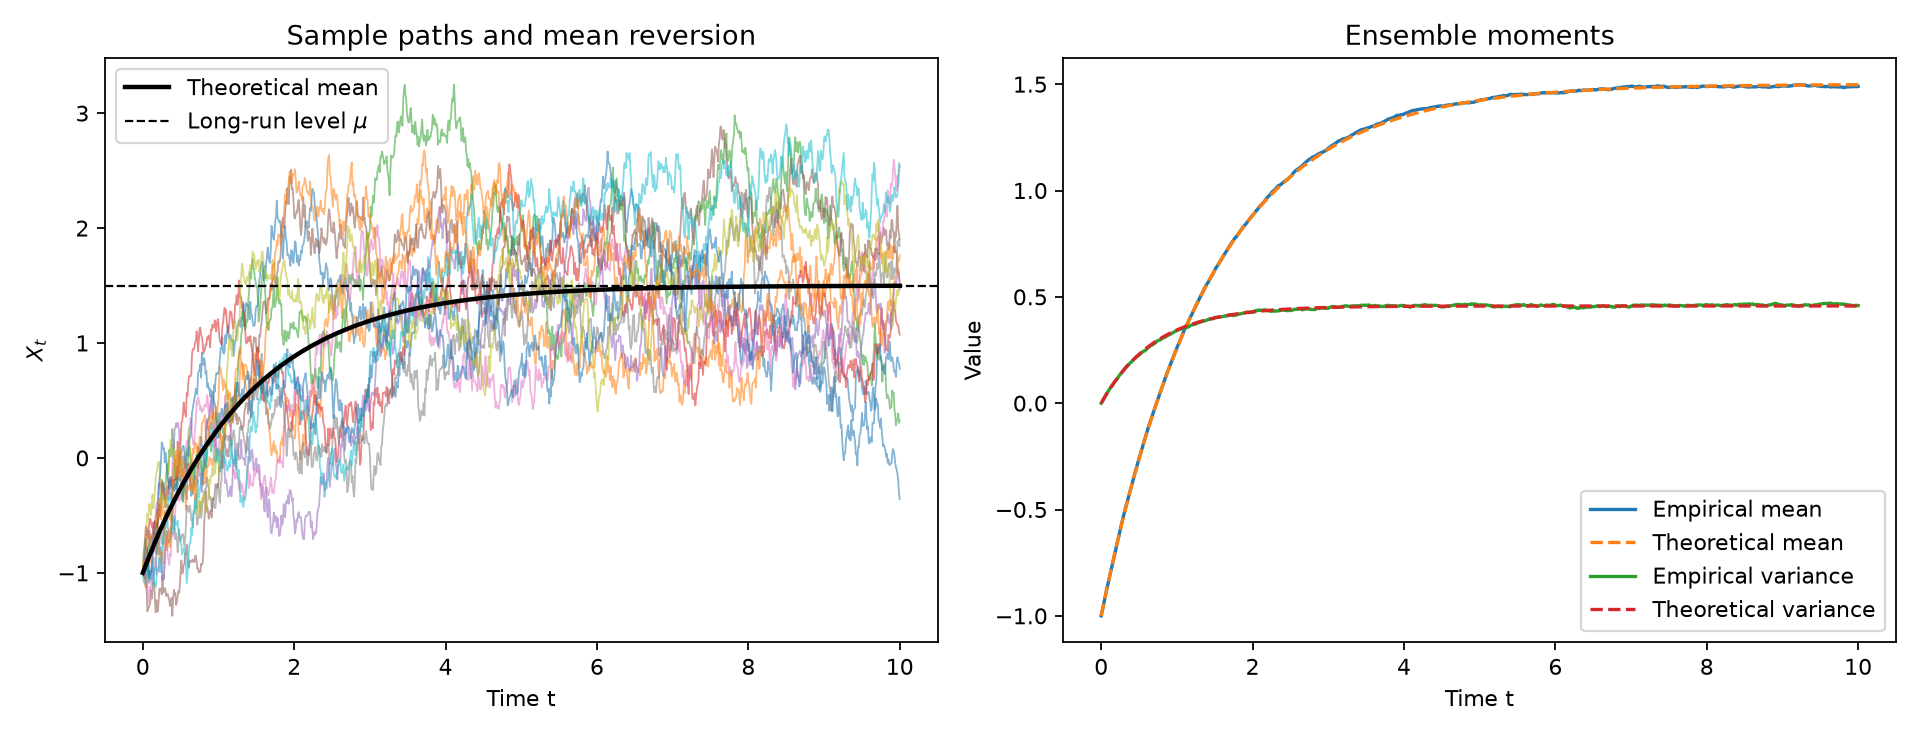

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for path in paths[:12]:
    axes[0].plot(times, path, alpha=0.55, linewidth=0.8)
axes[0].plot(times, theoretical_mean, color="black", linewidth=2, label="Theoretical mean")
axes[0].axhline(mu, color="black", linestyle="--", linewidth=1, label=r"Long-run level $\mu$")
axes[0].set(title="Sample paths and mean reversion", xlabel="Time t", ylabel=r"$X_t$")
axes[0].legend()

axes[1].plot(times, empirical_mean, label="Empirical mean")
axes[1].plot(times, theoretical_mean, "--", label="Theoretical mean")
axes[1].plot(times, empirical_variance, label="Empirical variance")
axes[1].plot(times, theoretical_variance, "--", label="Theoretical variance")
axes[1].set(title="Ensemble moments", xlabel="Time t", ylabel="Value")
axes[1].legend()
fig.tight_layout()
path = figure_dir / "ou_paths_and_moments.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

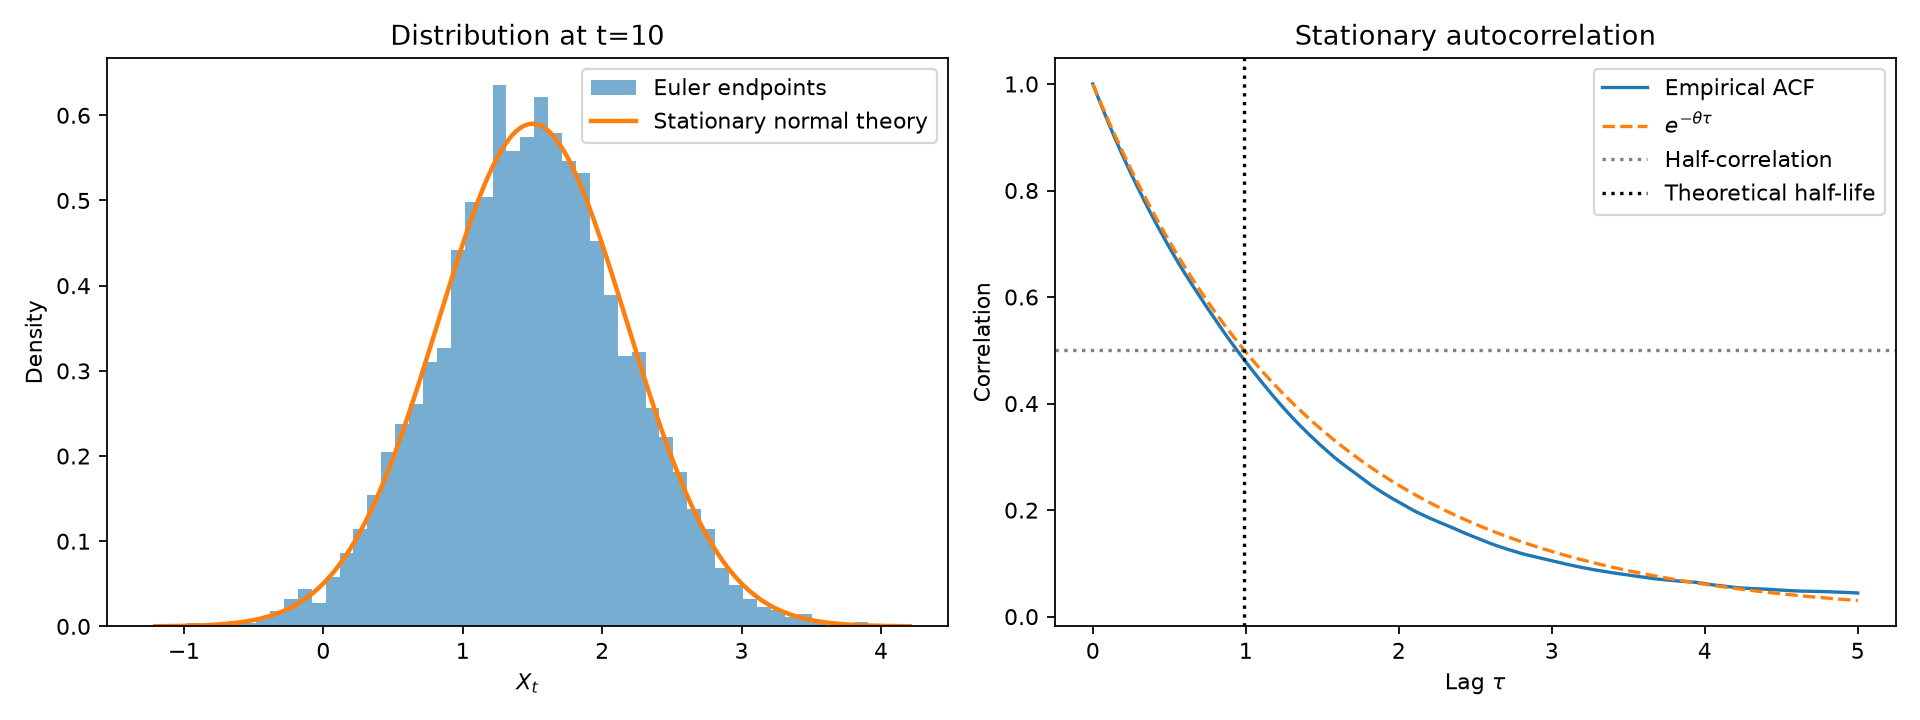

In [4]:
endpoints = paths[:, -1]
stationary_sd = np.sqrt(stationary_variance(theta, sigma))
x = np.linspace(mu - 4 * stationary_sd, mu + 4 * stationary_sd, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(endpoints, bins=55, density=True, alpha=0.6, label="Euler endpoints")
axes[0].plot(x, norm.pdf(x, loc=mu, scale=stationary_sd), linewidth=2,
             label="Stationary normal theory")
axes[0].set(title=f"Distribution at t={horizon:g}", xlabel=r"$X_t$", ylabel="Density")
axes[0].legend()

axes[1].plot(lag_times, empirical_acf, label="Empirical ACF")
axes[1].plot(lag_times, theoretical_acf, "--", label=r"$e^{-\theta\tau}$")
axes[1].axhline(0.5, color="gray", linestyle=":", label="Half-correlation")
axes[1].axvline(ou_half_life(theta), color="black", linestyle=":",
                label="Theoretical half-life")
axes[1].set(title="Stationary autocorrelation", xlabel=r"Lag $\tau$", ylabel="Correlation")
axes[1].legend()
fig.tight_layout()
path = figure_dir / "ou_stationary_distribution_and_acf.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

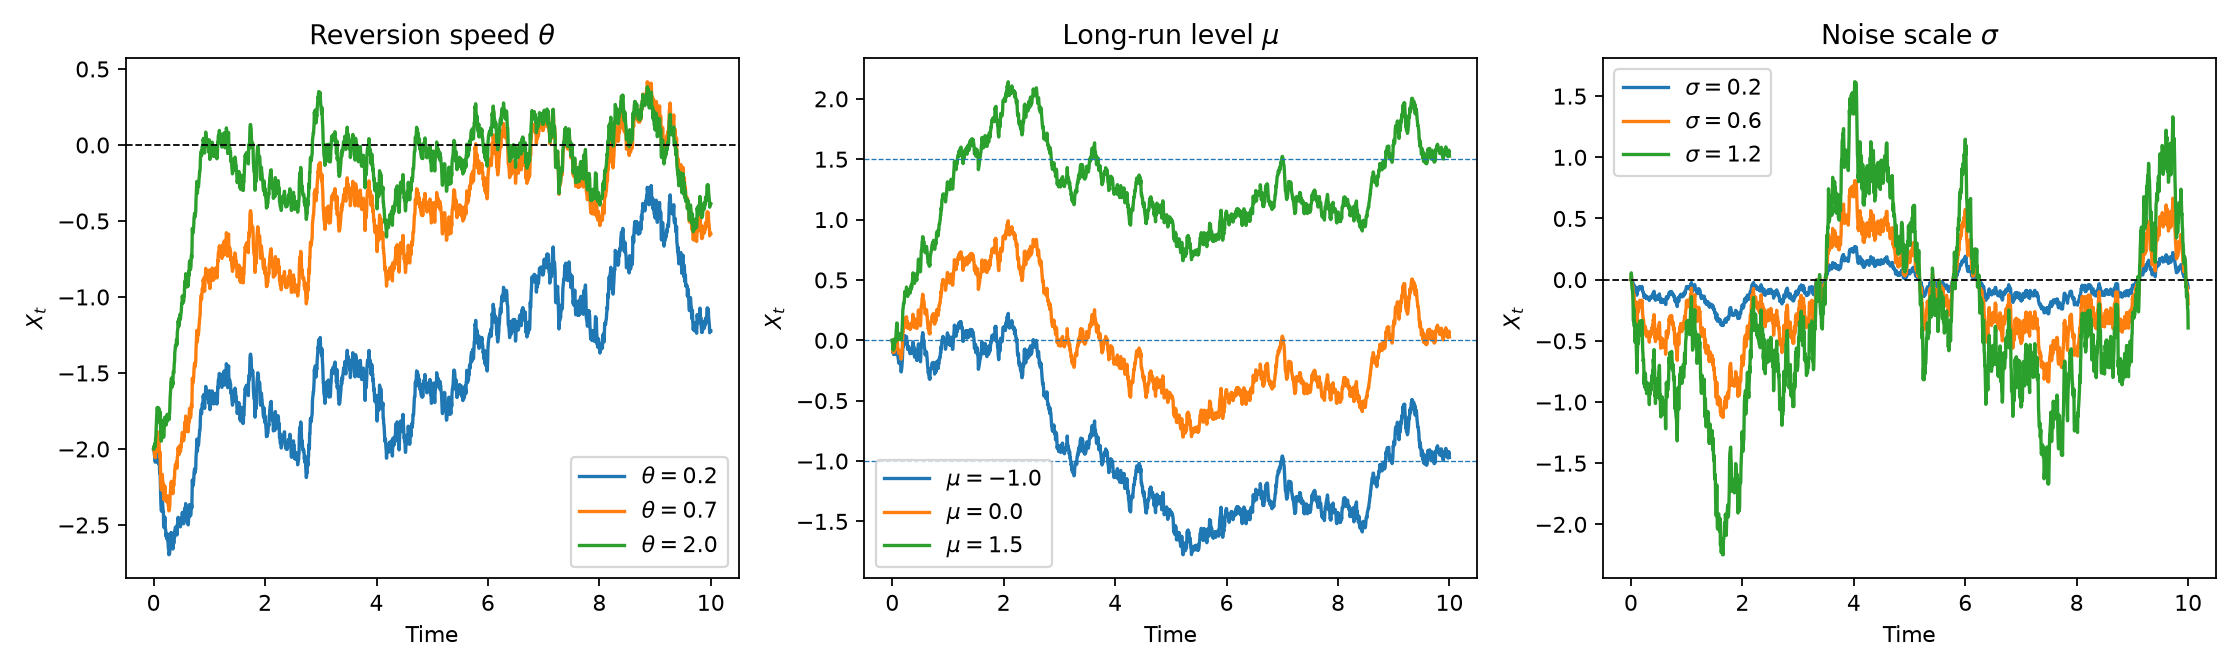

In [5]:
effect_dt, effect_horizon = 0.005, 10.0
effect_steps = int(effect_horizon / effect_dt)
effect_times = np.arange(effect_steps + 1) * effect_dt

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for value in (0.2, 0.7, 2.0):
    path_values = simulate_ou_euler(value, 0.0, 0.5, -2.0, effect_dt, effect_steps, 1,
                                    np.random.default_rng(20261003))[0]
    axes[0].plot(effect_times, path_values, label=fr"$\theta={value}$")
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set(title=r"Reversion speed $\theta$", xlabel="Time", ylabel=r"$X_t$")
axes[0].legend()

for value in (-1.0, 0.0, 1.5):
    path_values = simulate_ou_euler(0.7, value, 0.4, 0.0, effect_dt, effect_steps, 1,
                                    np.random.default_rng(20261004))[0]
    axes[1].plot(effect_times, path_values, label=fr"$\mu={value}$")
    axes[1].axhline(value, linestyle="--", linewidth=0.6)
axes[1].set(title=r"Long-run level $\mu$", xlabel="Time", ylabel=r"$X_t$")
axes[1].legend()

for value in (0.2, 0.6, 1.2):
    path_values = simulate_ou_euler(0.7, 0.0, value, 0.0, effect_dt, effect_steps, 1,
                                    np.random.default_rng(20261005))[0]
    axes[2].plot(effect_times, path_values, label=fr"$\sigma={value}$")
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set(title=r"Noise scale $\sigma$", xlabel="Time", ylabel=r"$X_t$")
axes[2].legend()
fig.tight_layout()
path = figure_dir / "ou_parameter_effects.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

## 6. Comparison with Theory

The empirical ensemble mean and variance follow the exact continuous-time curves. The endpoint histogram is close to the stationary normal density because ten time units correspond to roughly seven mean-reversion time scales for $\theta=0.7$.

The empirical autocorrelation follows $e^{-\theta\tau}$ and crosses 0.5 near $\log(2)/\theta$. Small discrepancies come from sampling variation, finite burn-in, and Euler discretization. Euler–Maruyama is itself a discrete autoregression with coefficient $1-\theta\Delta t$, so its exact lag-$k$ correlation is $(1-\theta\Delta t)^k$, which approaches $e^{-\theta k\Delta t}$ as $\Delta t\to0$.

## 7. Interpretation

Mean reversion is a statement about conditional drift: when $X_t>\mu$, the drift is negative, and when $X_t<\mu$, the drift is positive. It does not force every next movement toward $\mu$, because the Brownian shock can dominate over a short interval.

Increasing $\theta$ shortens the half-life and pulls deviations back faster. It also reduces stationary variance when $\sigma$ is fixed. Changing $\mu$ shifts the equilibrium level without directly changing fluctuation size. Increasing $\sigma$ produces larger random movements and increases stationary variance quadratically.

These properties make the OU process a useful first model for mean-reverting physical anomalies such as a simplified sea-surface-temperature anomaly, provided the scientific context supports approximately linear reversion and stationary noise.

## 8. Limitations

- Euler–Maruyama introduces discretization error. The time step must be small relative to the reversion time scale, and the recursion is unstable when $\theta\Delta t\geq2$.
- The basic OU process is Gaussian, stationary in the long run, and has constant parameters. Real environmental data can have seasonality, trends, non-Gaussian extremes, and time-varying dynamics.
- A single long trajectory contains dependent observations, so its histogram has less effective information than the same number of independent samples.
- Agreement of selected moments and autocorrelations does not prove that an observed dataset follows an OU model; model checking would require residual and out-of-sample analysis.